# NDVI Seasonal Variation Plot for Selected Polygon

This notebook reads your clear-mask shapefile, lets you choose a polygon by FID, and calculates NDVI seasonal variation for that polygon.

It avoids loading all rasters into memory at once. Your original `np.stack(arrays)` approach can stall because it tries to hold 10 years of raster data in RAM.


In [1]:
from pathlib import Path
from datetime import datetime
import re

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt

try:
    from scipy.ndimage import gaussian_filter1d
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

plt.rcParams["figure.dpi"] = 120


## 1. Set paths

In [25]:
shp_path = Path("/home/jovyan/scratch/eds-work-processing/p089r078/run-auto-scale/maskvec_work/vectors/clear/l9olre_p089r078_d2025070120260117_dlj-dlj-clear-ge80_e32756.shp")
ndvi_dir = Path("/home/jovyan/scratch/eds-work-processing/p089r078/run-auto-scale/ga1_stage")
tile = "p089r078"

ndvi_files = sorted(ndvi_dir.glob("*.tif"))

print(f"Shapefile exists: {shp_path.exists()}")
print(f"NDVI rasters found: {len(ndvi_files)}")
print(ndvi_files[:3])


Shapefile exists: True
NDVI rasters found: 185
[PosixPath('/home/jovyan/scratch/eds-work-processing/p089r078/run-auto-scale/ga1_stage/sl8olre_p089r078_20150212_ga1-clr_e32756.tif'), PosixPath('/home/jovyan/scratch/eds-work-processing/p089r078/run-auto-scale/ga1_stage/sl8olre_p089r078_20150228_ga1-clr_e32756.tif'), PosixPath('/home/jovyan/scratch/eds-work-processing/p089r078/run-auto-scale/ga1_stage/sl8olre_p089r078_20150316_ga1-clr_e32756.tif')]


## 2. Load shapefile and inspect polygons

Set `POLYGON_FID` in the next section to the polygon you want to analyse.


In [26]:
gdf = gpd.read_file(shp_path)

print("CRS:", gdf.crs)
print("Rows/columns:", gdf.shape)
display(gdf.head())

# If there is no FID column, create one from the row index.
if "FID" not in gdf.columns:
    gdf = gdf.reset_index().rename(columns={"index": "FID"})

display(gdf[["FID", "geometry"]].head(20))


CRS: EPSG:32756
Rows/columns: (131, 3)


,value,area_ha,geometry
0,1,17.37,"POLYGON ((489660 7194060, 489720 7194060, 4897..."
1,1,12.51,"POLYGON ((511710 7180440, 511770 7180440, 5117..."
2,1,33.03,"POLYGON ((512100 7180020, 512160 7180020, 5121..."
3,1,11.88,"POLYGON ((511260 7179180, 511290 7179180, 5112..."
4,1,10.62,"POLYGON ((499320 7173030, 499440 7173030, 4994..."


,FID,geometry
0,0,"POLYGON ((489660 7194060, 489720 7194060, 4897..."
1,1,"POLYGON ((511710 7180440, 511770 7180440, 5117..."
2,2,"POLYGON ((512100 7180020, 512160 7180020, 5121..."
3,3,"POLYGON ((511260 7179180, 511290 7179180, 5112..."
4,4,"POLYGON ((499320 7173030, 499440 7173030, 4994..."
5,5,"POLYGON ((503760 7172820, 503790 7172820, 5037..."
6,6,"POLYGON ((501210 7170570, 501240 7170570, 5012..."
7,7,"POLYGON ((506730 7163520, 506820 7163520, 5068..."
8,8,"POLYGON ((483660 7163250, 483750 7163250, 4837..."
9,9,"POLYGON ((482040 7159620, 482130 7159620, 4821..."


## 3. Choose polygon FID

Selected FID: 40
Polygon area in CRS units: 204,300.00


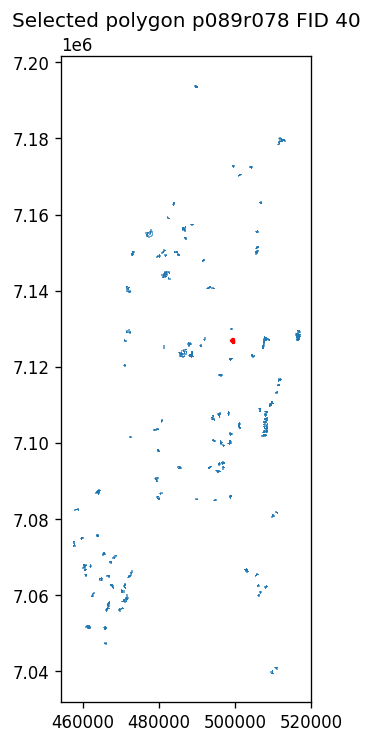

In [28]:
POLYGON_FID = 40  # change this to your target polygon FID

poly_row = gdf.loc[gdf["FID"] == POLYGON_FID]

if poly_row.empty:
    raise ValueError(f"No polygon found with FID={POLYGON_FID}")

poly = poly_row.iloc[0]
poly_geom = poly.geometry

print(f"Selected FID: {POLYGON_FID}")
print(f"Polygon area in CRS units: {poly_geom.area:,.2f}")

ax = gdf.boundary.plot(figsize=(7, 7), linewidth=0.4)
gpd.GeoSeries([poly_geom], crs=gdf.crs).boundary.plot(ax=ax, color="red", linewidth=2)
ax.set_title(f"Selected polygon {tile} FID {POLYGON_FID}")
plt.show()


Selected FID: 40
Polygon area in CRS units: 204,300.00


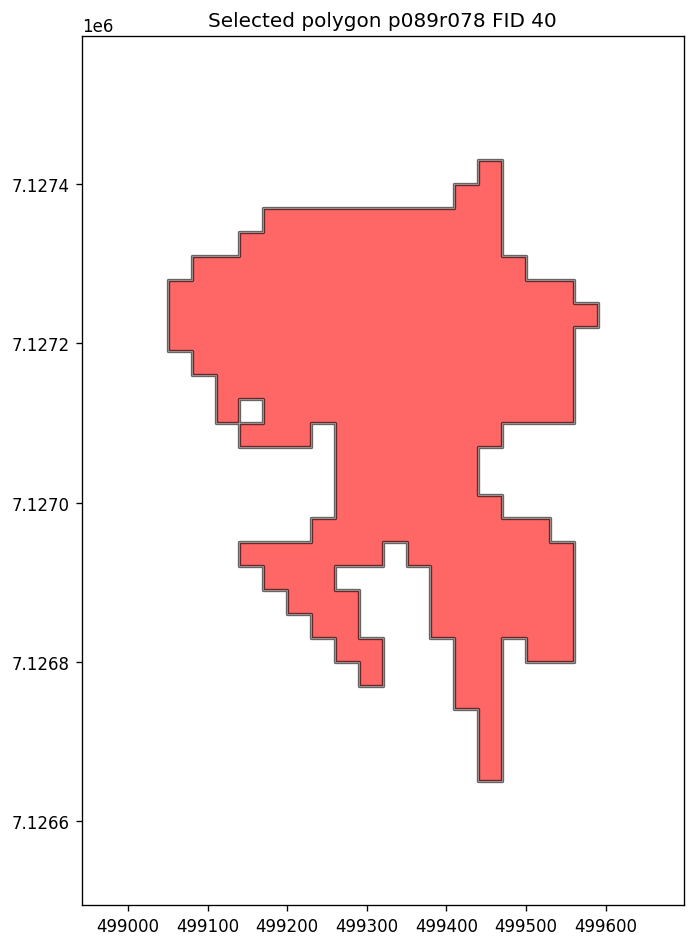

In [29]:
# POLYGON_FID = 0  # change this to your target polygon FID

poly_row = gdf.loc[gdf["FID"] == POLYGON_FID]

if poly_row.empty:
    raise ValueError(f"No polygon found with FID={POLYGON_FID}")

poly = poly_row.iloc[0]
poly_geom = poly.geometry

print(f"Selected FID: {POLYGON_FID}")
print(f"Polygon area in CRS units: {poly_geom.area:,.2f}")

# Create plot
fig, ax = plt.subplots(figsize=(8, 8))

# Plot all polygon outlines lightly
gdf.boundary.plot(
    ax=ax,
    linewidth=0.3,
    color="lightgrey"
)

# Plot selected polygon filled
gpd.GeoSeries(
    [poly_geom],
    crs=gdf.crs
).plot(
    ax=ax,
    facecolor="red",
    edgecolor="black",
    linewidth=2,
    alpha=0.6
)

# Zoom to polygon bounds
minx, miny, maxx, maxy = poly_geom.bounds

# Add padding
pad_x = (maxx - minx) * 0.2
pad_y = (maxy - miny) * 0.2

ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)

ax.set_title(f"Selected polygon {tile} FID {POLYGON_FID}")

plt.tight_layout()
plt.show()

## 4. Parse dates from filenames

This tries:
- a direct `YYYYMMDD` token
- a date-range token like `d2025070120260117`
- the first `YYYYMMDD` anywhere in the filename


In [16]:
def parse_date_from_filename(path: Path):
    stem = path.stem
    parts = stem.split("_")

    if len(parts) > 2:
        token = parts[2]

        if re.fullmatch(r"\d{8}", token):
            return datetime.strptime(token, "%Y%m%d")

        m = re.match(r"d(\d{8})(\d{8})?", token)
        if m:
            return datetime.strptime(m.group(1), "%Y%m%d")

    m = re.search(r"(20\d{6}|19\d{6})", stem)
    if m:
        return datetime.strptime(m.group(1), "%Y%m%d")

    raise ValueError(f"Could not parse date from {path.name}")


records = []

for f in ndvi_files:
    try:
        records.append({"path": f, "date": parse_date_from_filename(f)})
    except Exception as e:
        print("Skipping:", f.name, e)

files_df = pd.DataFrame(records).sort_values("date").reset_index(drop=True)

display(files_df.head())
display(files_df.tail())
print(files_df["date"].min(), "to", files_df["date"].max())


,path,date
0,/home/jovyan/scratch/eds-work-processing/p089r...,2015-02-12
1,/home/jovyan/scratch/eds-work-processing/p089r...,2015-02-28
2,/home/jovyan/scratch/eds-work-processing/p089r...,2015-03-16
3,/home/jovyan/scratch/eds-work-processing/p089r...,2015-05-03
4,/home/jovyan/scratch/eds-work-processing/p089r...,2015-05-19


,path,date
180,/home/jovyan/scratch/eds-work-processing/p089r...,2025-12-08
181,/home/jovyan/scratch/eds-work-processing/p089r...,2026-01-17
182,/home/jovyan/scratch/eds-work-processing/p089r...,2026-01-25
183,/home/jovyan/scratch/eds-work-processing/p089r...,2026-02-10
184,/home/jovyan/scratch/eds-work-processing/p089r...,2026-02-18


2015-02-12 00:00:00 to 2026-02-18 00:00:00


## 5. Calculate polygon NDVI through time

This opens one raster at a time, clips only the selected polygon, calculates statistics, and then closes the raster.


In [17]:
def summarise_ndvi_for_polygon(raster_path, geom, geom_crs):
    with rasterio.open(raster_path) as src:
        if geom_crs != src.crs:
            geom_use = gpd.GeoSeries([geom], crs=geom_crs).to_crs(src.crs).iloc[0]
        else:
            geom_use = geom

        try:
            out, _ = mask(src, [geom_use], crop=True, filled=False)
        except ValueError:
            return {
                "mean": np.nan,
                "median": np.nan,
                "p10": np.nan,
                "p90": np.nan,
                "valid_pixels": 0,
            }

        arr = out[0].astype("float32")

        if np.ma.isMaskedArray(arr):
            arr = arr.filled(np.nan)

        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan

        arr[(arr < -1) | (arr > 1)] = np.nan

        valid = np.isfinite(arr)
        n = int(valid.sum())

        if n == 0:
            return {
                "mean": np.nan,
                "median": np.nan,
                "p10": np.nan,
                "p90": np.nan,
                "valid_pixels": 0,
            }

        vals = arr[valid]

        return {
            "mean": float(np.nanmean(vals)),
            "median": float(np.nanmedian(vals)),
            "p10": float(np.nanpercentile(vals, 10)),
            "p90": float(np.nanpercentile(vals, 90)),
            "valid_pixels": n,
        }


rows = []

for i, r in files_df.iterrows():
    stats = summarise_ndvi_for_polygon(r["path"], poly_geom, gdf.crs)
    rows.append({
        "date": r["date"],
        "path": r["path"],
        **stats,
    })

    if (i + 1) % 25 == 0 or i == len(files_df) - 1:
        print(f"Processed {i + 1}/{len(files_df)}")

ts = pd.DataFrame(rows)
ts["doy"] = ts["date"].dt.dayofyear
ts["year"] = ts["date"].dt.year

ts_valid = ts.dropna(subset=["mean"]).copy()

display(ts_valid.head())
print(f"Valid observations: {len(ts_valid)} / {len(ts)}")


Processed 25/185
Processed 50/185
Processed 75/185
Processed 100/185
Processed 125/185
Processed 150/185
Processed 175/185
Processed 185/185


,date,path,mean,median,p10,p90,valid_pixels,doy,year
0,2015-02-12,/home/jovyan/scratch/eds-work-processing/p089r...,0.577060,0.620064,0.376954,0.705157,176,43,2015
1,2015-02-28,/home/jovyan/scratch/eds-work-processing/p089r...,0.591975,0.581640,0.431169,0.762304,97,59,2015
2,2015-03-16,/home/jovyan/scratch/eds-work-processing/p089r...,0.583803,0.580042,0.470157,0.698404,227,75,2015
3,2015-05-03,/home/jovyan/scratch/eds-work-processing/p089r...,0.760880,0.767422,0.694644,0.812587,227,123,2015
4,2015-05-19,/home/jovyan/scratch/eds-work-processing/p089r...,0.692360,0.708088,0.591234,0.777950,227,139,2015


Valid observations: 162 / 185


## 6. Plot raw polygon NDVI time series

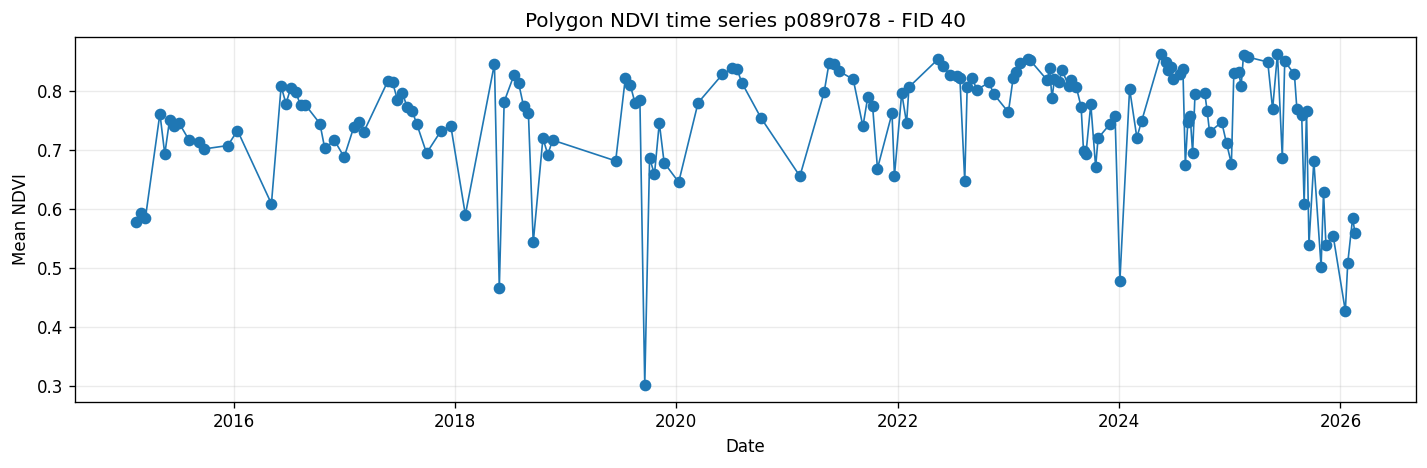

In [30]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(ts_valid["date"], ts_valid["mean"], marker="o", linewidth=1)
ax.set_title(f"Polygon NDVI time series {tile} - FID {POLYGON_FID}")
ax.set_xlabel("Date")
ax.set_ylabel("Mean NDVI")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


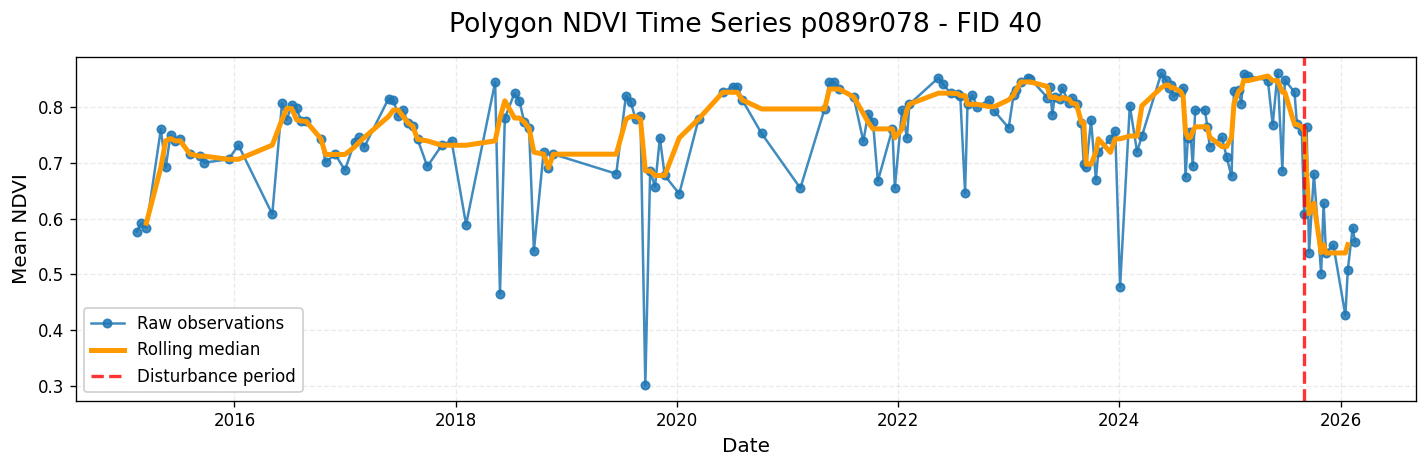

In [31]:
fig, ax = plt.subplots(
    figsize=(12, 4),
    facecolor="white"
)

# Light background
ax.set_facecolor("white")

# Ensure sorted by date
ts_valid = ts_valid.sort_values("date")

# Raw NDVI observations
ax.plot(
    ts_valid["date"],
    ts_valid["mean"],
    marker="o",
    linewidth=1.5,
    markersize=5,
    color="#1f77b4",
    alpha=0.85,
    label="Raw observations"
)

# Rolling median smoothing
ts_valid["rolling"] = (
    ts_valid["mean"]
    .rolling(window=5, center=True)
    .median()
)

ax.plot(
    ts_valid["date"],
    ts_valid["rolling"],
    linewidth=3,
    color="#ff9900",
    label="Rolling median"
)

# Optional disturbance marker
ax.axvline(
    pd.Timestamp("2025-09-01"),
    color="red",
    linestyle="--",
    linewidth=2,
    alpha=0.8,
    label="Disturbance period"
)

# Titles and labels
ax.set_title(
    f"Polygon NDVI Time Series {tile} - FID {POLYGON_FID}",
    fontsize=16,
    pad=15
)

ax.set_xlabel(
    "Date",
    fontsize=12
)

ax.set_ylabel(
    "Mean NDVI",
    fontsize=12
)

# Grid styling
ax.grid(
    alpha=0.25,
    linestyle="--"
)

# Legend
ax.legend(
    framealpha=0.95
)

plt.tight_layout()

plt.savefig(
    f"polygon_ndvi_timeseries_light_fid_{POLYGON_FID}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

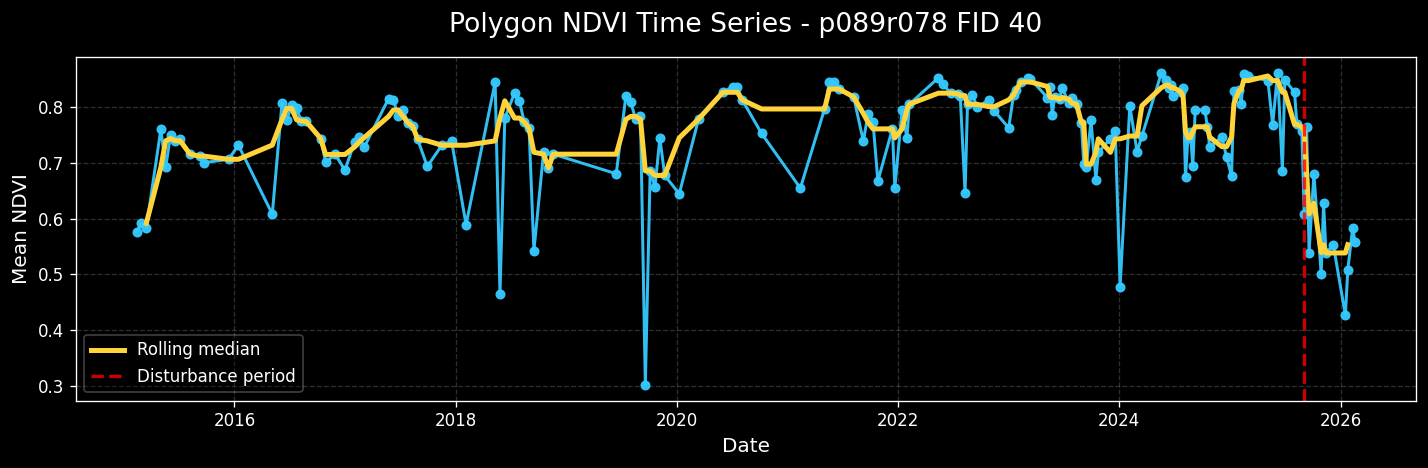

In [33]:
fig, ax = plt.subplots(
    figsize=(12, 4),
    facecolor="black"
)

# Dark background
ax.set_facecolor("black")

# Raw NDVI observations
ax.plot(
    ts_valid["date"],
    ts_valid["mean"],
    marker="o",
    linewidth=1.8,
    markersize=5,
    color="#35c9ff",
    alpha=0.95,
)

# Optional rolling median smoothing
ts_valid = ts_valid.sort_values("date")

ts_valid["rolling"] = (
    ts_valid["mean"]
    .rolling(window=5, center=True)
    .median()
)

ax.plot(
    ts_valid["date"],
    ts_valid["rolling"],
    linewidth=3,
    color="#ffd43b",
    label="Rolling median"
)

# Styling
ax.set_title(
    f"Polygon NDVI Time Series - {tile} FID {POLYGON_FID}",
    color="white",
    fontsize=16,
    pad=15,
)

ax.set_xlabel(
    "Date",
    color="white",
    fontsize=12,
)

ax.set_ylabel(
    "Mean NDVI",
    color="white",
    fontsize=12,
)

# Tick colours
ax.tick_params(
    axis="x",
    colors="white"
)

ax.tick_params(
    axis="y",
    colors="white"
)

# Grid
ax.grid(
    alpha=0.18,
    color="white",
    linestyle="--"
)

# White axes
for spine in ax.spines.values():
    spine.set_color("white")

# Optional clearing period marker
ax.axvline(
    pd.Timestamp("2025-09-01"),
    color="red",
    linestyle="--",
    linewidth=2,
    alpha=0.8,
    label="Disturbance period"
)

# Legend
leg = ax.legend(
    facecolor="black",
    edgecolor="white",
    framealpha=0.25
)

for text in leg.get_texts():
    text.set_color("white")

plt.tight_layout()

plt.savefig(
    f"polygon_ndvi_timeseries_dark_fid_{POLYGON_FID}.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()

## 7. Seasonal variation and current anomaly

This collapses all years by day-of-year to create the historical seasonal baseline.


In [19]:
seasonal = ts_valid.groupby("doy")["mean"].agg(
    seasonal_mean="mean",
    seasonal_median="median",
    p10=lambda x: np.nanpercentile(x, 10),
    p90=lambda x: np.nanpercentile(x, 90),
    n="count",
).reset_index()

if SCIPY_AVAILABLE and len(seasonal) > 5:
    sigma = 2
    seasonal["seasonal_mean_smooth"] = gaussian_filter1d(seasonal["seasonal_mean"].to_numpy(), sigma=sigma)
    seasonal["p10_smooth"] = gaussian_filter1d(seasonal["p10"].to_numpy(), sigma=sigma)
    seasonal["p90_smooth"] = gaussian_filter1d(seasonal["p90"].to_numpy(), sigma=sigma)
else:
    seasonal["seasonal_mean_smooth"] = seasonal["seasonal_mean"]
    seasonal["p10_smooth"] = seasonal["p10"]
    seasonal["p90_smooth"] = seasonal["p90"]

current = ts_valid.sort_values("date").iloc[-1]
current_doy = int(current["doy"])

nearest_idx = (seasonal["doy"] - current_doy).abs().idxmin()
expected = float(seasonal.loc[nearest_idx, "seasonal_mean_smooth"])
anomaly = float(current["mean"] - expected)

print("Current date:", current["date"].date())
print("Current DOY:", current_doy)
print("Current NDVI:", round(float(current["mean"]), 4))
print("Expected seasonal NDVI:", round(expected, 4))
print("Anomaly:", round(anomaly, 4))


Current date: 2026-02-18
Current DOY: 49
Current NDVI: 0.5587
Expected seasonal NDVI: 0.6913
Anomaly: -0.1326


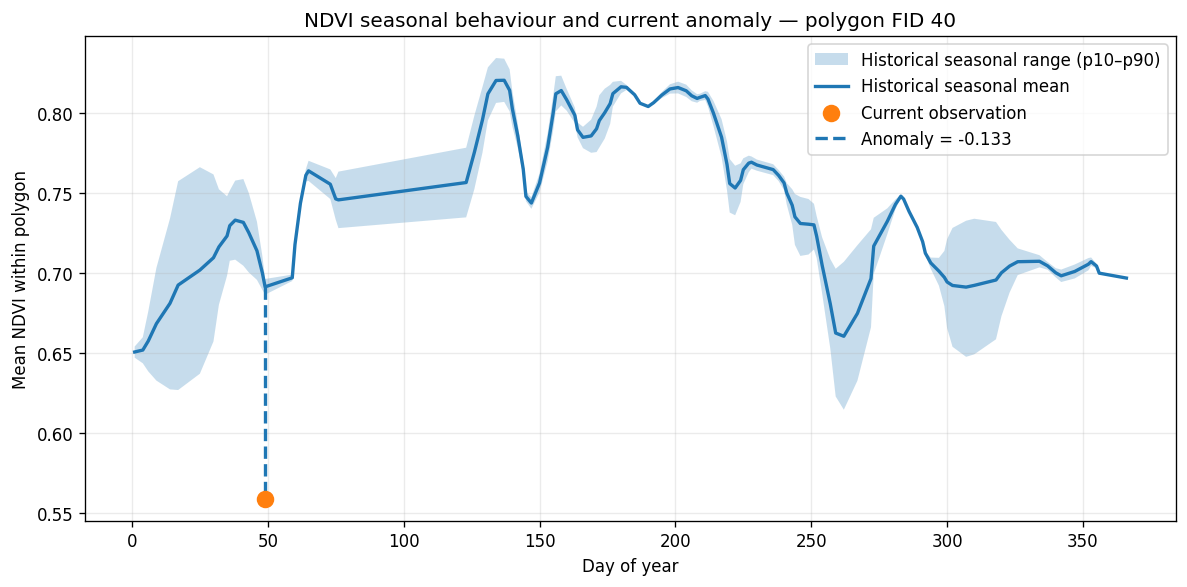

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.fill_between(
    seasonal["doy"],
    seasonal["p10_smooth"],
    seasonal["p90_smooth"],
    alpha=0.25,
    label="Historical seasonal range (p10–p90)",
)

ax.plot(
    seasonal["doy"],
    seasonal["seasonal_mean_smooth"],
    linewidth=2,
    label="Historical seasonal mean",
)

ax.scatter(
    current_doy,
    current["mean"],
    s=90,
    zorder=5,
    label="Current observation",
)

ax.vlines(
    current_doy,
    expected,
    current["mean"],
    linestyles="--",
    linewidth=2,
    label=f"Anomaly = {anomaly:+.3f}",
)

ax.set_title(f"NDVI seasonal behaviour and current anomaly — polygon FID {POLYGON_FID}")
ax.set_xlabel("Day of year")
ax.set_ylabel("Mean NDVI within polygon")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.savefig(f"ndvi_seasonal_anomaly_fid_{POLYGON_FID}.png", dpi=300, bbox_inches="tight")
plt.show()


## 8. Optional dark presentation version

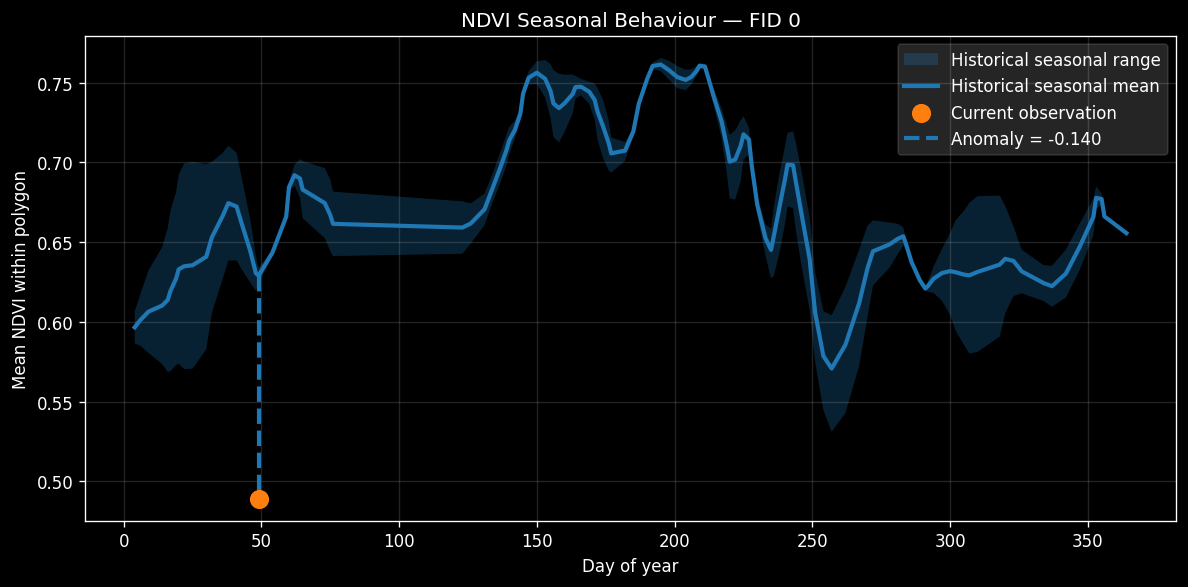

In [10]:
fig, ax = plt.subplots(figsize=(10, 5), facecolor="black")
ax.set_facecolor("black")

ax.fill_between(
    seasonal["doy"],
    seasonal["p10_smooth"],
    seasonal["p90_smooth"],
    alpha=0.28,
    label="Historical seasonal range",
)

ax.plot(
    seasonal["doy"],
    seasonal["seasonal_mean_smooth"],
    linewidth=2.5,
    label="Historical seasonal mean",
)

ax.scatter(
    current_doy,
    current["mean"],
    s=110,
    zorder=5,
    label="Current observation",
)

ax.vlines(
    current_doy,
    expected,
    current["mean"],
    linestyles="--",
    linewidth=2.5,
    label=f"Anomaly = {anomaly:+.3f}",
)

ax.set_title(f"NDVI Seasonal Behaviour — FID {POLYGON_FID}", color="white")
ax.set_xlabel("Day of year", color="white")
ax.set_ylabel("Mean NDVI within polygon", color="white")
ax.tick_params(colors="white")
ax.grid(alpha=0.2)

for spine in ax.spines.values():
    spine.set_color("white")

leg = ax.legend(framealpha=0.15)
for text in leg.get_texts():
    text.set_color("white")

plt.tight_layout()
plt.savefig(f"ndvi_seasonal_anomaly_fid_{POLYGON_FID}_dark.png", dpi=300, transparent=True, bbox_inches="tight")
plt.show()


## Notes

The plot is for the selected polygon only, not the whole tile.

The notebook calculates one NDVI summary value per raster for that polygon, then builds:

- raw NDVI time series
- seasonal mean
- seasonal p10–p90 envelope
- current observation
- anomaly from expected seasonal behaviour
